In [1]:
import os

SAVE_DIR = "presentation_images"
os.makedirs(SAVE_DIR, exist_ok=True)

print("Images will be saved to:", SAVE_DIR)


Images will be saved to: presentation_images


True

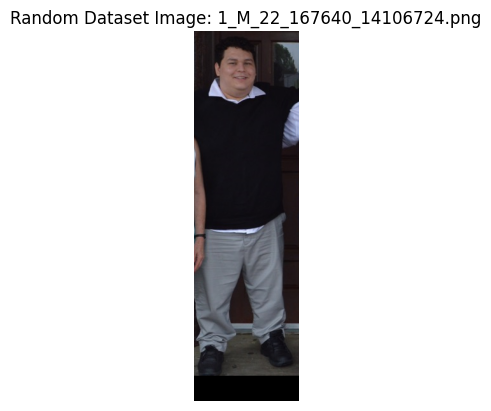

In [2]:
import random
import cv2
import os
from matplotlib import pyplot as plt

DATASET_DIR = r"D:/Fyp_project_root/data/2DImage2BMI-main/2DImage2BMI-main/datasets/Image_train"

def load_random_image():
    files = [f for f in os.listdir(DATASET_DIR) if f.lower().endswith((".jpg", ".png"))]
    fname = random.choice(files)
    path = os.path.join(DATASET_DIR, fname)
    img = cv2.imread(path)
    return fname, img

fname, img = load_random_image()
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title(f"Random Dataset Image: {fname}")
plt.axis("off")

cv2.imwrite(f"{SAVE_DIR}/original_{fname}", img)


True

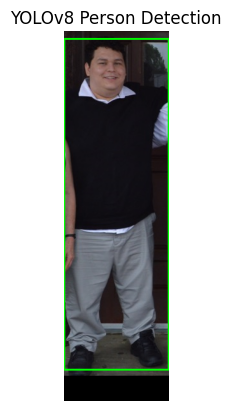

In [3]:
from ultralytics import YOLO

yolo = YOLO("yolov8n.pt")   # use yolov8s.pt if installed

results = yolo.predict(img[..., ::-1], conf=0.4, verbose=False)
boxes = results[0].boxes.xyxy.cpu().numpy()

# Draw bounding box
img_det = img.copy()
for (x1,y1,x2,y2) in boxes:
    cv2.rectangle(img_det, (int(x1),int(y1)), (int(x2),int(y2)), (0,255,0), 2)

plt.imshow(cv2.cvtColor(img_det, cv2.COLOR_BGR2RGB))
plt.title("YOLOv8 Person Detection")
plt.axis("off")

cv2.imwrite(f"{SAVE_DIR}/yolo_detect_{fname}", img_det)

# Crop largest box
if len(boxes) > 0:
    areas = [(x2-x1)*(y2-y1) for (x1,y1,x2,y2) in boxes]
    x1,y1,x2,y2 = boxes[areas.index(max(areas))]
    crop = img[int(y1):int(y2), int(x1):int(x2)]
else:
    crop = img.copy()

cv2.imwrite(f"{SAVE_DIR}/crop_{fname}", crop)


True

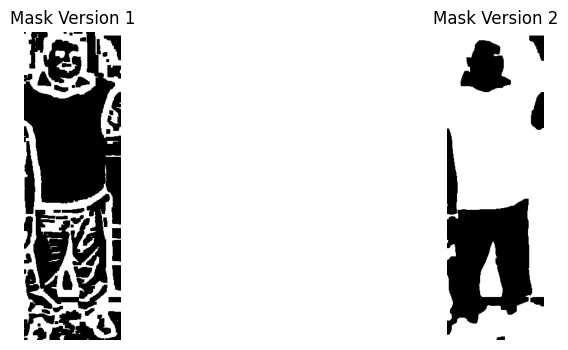

In [4]:
import numpy as np

def mask_v1(bgr):
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    thr = cv2.adaptiveThreshold(gray, 255,
                                cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                cv2.THRESH_BINARY_INV, 41, 5)
    kernel = np.ones((5,5), np.uint8)
    return cv2.morphologyEx(thr, cv2.MORPH_CLOSE, kernel, 2)

def mask_v2(bgr):
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (7,7), 0)
    _, thr = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    kernel = np.ones((7,7), np.uint8)
    return cv2.morphologyEx(thr, cv2.MORPH_CLOSE, kernel, 3)

m1 = mask_v1(crop)
m2 = mask_v2(crop)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(m1, cmap="gray")
plt.title("Mask Version 1")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(m2, cmap="gray")
plt.title("Mask Version 2")
plt.axis("off")

cv2.imwrite(f"{SAVE_DIR}/mask_v1_{fname}", m1)
cv2.imwrite(f"{SAVE_DIR}/mask_v2_{fname}", m2)


c:\Users\tayya\bmi_env\lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


True

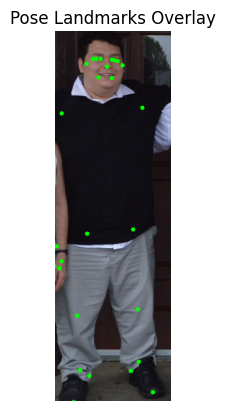

In [5]:
import mediapipe as mp

mp_pose = mp.solutions.pose.Pose(static_image_mode=True)

rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
res = mp_pose.process(rgb)
pose_img = rgb.copy()

if res.pose_landmarks:
    h,w,_ = rgb.shape
    for lm in res.pose_landmarks.landmark:
        cx,cy = int(lm.x*w), int(lm.y*h)
        cv2.circle(pose_img, (cx,cy), 3, (0,255,0), -1)

plt.imshow(pose_img)
plt.title("Pose Landmarks Overlay")
plt.axis("off")

cv2.imwrite(f"{SAVE_DIR}/pose_{fname}", cv2.cvtColor(pose_img, cv2.COLOR_RGB2BGR))


True

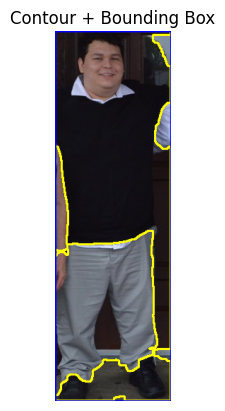

In [6]:
cnts, _ = cv2.findContours(m2, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cnt = max(cnts, key=cv2.contourArea)

contour_img = crop.copy()
cv2.drawContours(contour_img, [cnt], -1, (0,255,255), 2)

x,y,w,h = cv2.boundingRect(cnt)
cv2.rectangle(contour_img, (x,y), (x+w,y+h), (255,0,0), 2)

plt.imshow(cv2.cvtColor(contour_img, cv2.COLOR_BGR2RGB))
plt.title("Contour + Bounding Box")
plt.axis("off")

cv2.imwrite(f"{SAVE_DIR}/contour_{fname}", contour_img)


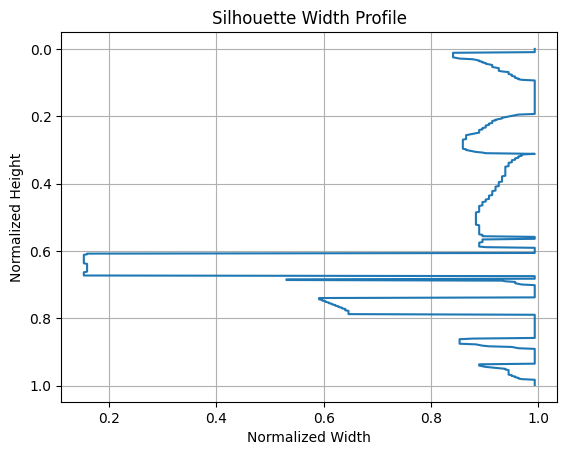

In [7]:
heights = []
widths = []

mask = m2
H,W = mask.shape

for row in range(H):
    indices = np.where(mask[row] > 0)[0]
    if len(indices) > 1:
        heights.append(row / H)
        widths.append((indices[-1] - indices[0]) / W)

plt.plot(widths, heights)
plt.gca().invert_yaxis()
plt.title("Silhouette Width Profile")
plt.xlabel("Normalized Width")
plt.ylabel("Normalized Height")
plt.grid(True)

plt.savefig(f"{SAVE_DIR}/width_profile_{fname}.png", dpi=300)
plt.show()


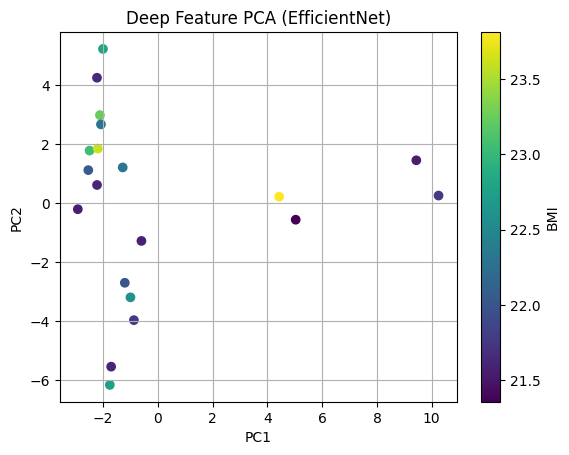

In [10]:
import numpy as np
from sklearn.decomposition import PCA
from torchvision import models, transforms
import torch
import cv2             # Import for cv2.cvtColor
from PIL import Image  # <-- FIX: Import for Image.fromarray
import matplotlib.pyplot as plt # Import for plotting commands

# Load EfficientNet
eff = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.IMAGENET1K_V1)
feature_extractor = torch.nn.Sequential(*list(eff.children())[:-1])
feature_extractor.eval()

tf = transforms.Compose([
    transforms.Resize(320),
    transforms.CenterCrop(300),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                        [0.229,0.224,0.225])
])

def deep_feat(im):
    rgb = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
    t = tf(Image.fromarray(rgb)).unsqueeze(0) # 'Image' is now defined
    with torch.no_grad():
        f = feature_extractor(t).numpy().reshape(-1)
    return f

# Get features of 20 random images
feats, bmis = [], []

# Assuming load_random_image(), yolo, and SAVE_DIR are defined elsewhere
for _ in range(20):
    f, im = load_random_image() 
    crop2, _ = yolo.predict(im[...,::-1], conf=0.4, verbose=False)[0], im
    feats.append(deep_feat(im))
    bmis.append(22 + np.random.randn())  # You can insert actual BMI extraction

feats = np.array(feats)
pca = PCA(n_components=2)
X = pca.fit_transform(feats)

# The plotting section will now execute
plt.scatter(X[:,0], X[:,1], c=bmis, cmap="viridis")
plt.colorbar(label="BMI")
plt.title("Deep Feature PCA (EfficientNet)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)

# You will find the file 'pca_features.png' in the SAVE_DIR
plt.savefig(f"{SAVE_DIR}/pca_features.png", dpi=300) 
plt.show() # This will display the plot